# Backbone comparison: DINOv2 vs DINOv3 autoencoders on RELLIS-3D

We train a **brand-new** STEPP-style autoencoder **from scratch** (random weights — *not* the
pretrained STEPP weights) on RELLIS-3D, once for **DINOv2** features and once for **DINOv3**
features, using the exact same steps. The only difference between the two runs is which vision
model produces the features. Then we compare how well each separates traversable ground from
obstacles on a held-out sequence.

The steps for each backbone are:
1. **Features** – for every training image, take the future-path segments (`pixels.json`), run the backbone, and average one feature vector per path segment.
2. **Train** – a small autoencoder learns to rebuild those traversable vectors (MSE loss).
3. **Evaluate** – on the held-out sequence, the reconstruction error of each segment is the
   *cost* (low = traversable). We score the cost against the RELLIS labels.

**Patch-size difference (important):**
- DINOv2 ViT-S/14 → image 700×700, patch 14 → **50×50** grid of features.
- DINOv3 ViT-S/16 → image 704×704, patch 16 → **44×44** grid of features.

Both give **384**-length vectors, so the autoencoder is identical for both.

The code below is written to be easy to read: small named functions and simple loops.

## 0. Settings

In [2]:
from pathlib import Path

DATA_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/Rellis_3D')
OUT_ROOT  = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/outputs')
COMP_DIR  = OUT_ROOT / 'comp_v2v3'
COMP_DIR.mkdir(parents=True, exist_ok=True)

# where the DINOv3 code and weights live
DINOV3_REPO    = Path('C:/Users/jthre/.cache/torch/hub/facebookresearch_dinov3_main')
DINOV3_WEIGHTS = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/DinoV3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth')

# which backbones to run
BACKBONES = ['dinov2', 'dinov3']

# sequences: train on four, keep 00002 aside for testing
TRAIN_SEQS = ['00000', '00001', '00003', '00004']
HOLDOUT    = '00002'

# original RELLIS image size (path pixels in pixels.json use these coordinates)
IMG_W, IMG_H = 1920, 1200

# SLIC superpixel settings (same as the rest of the project)
N_SEGMENTS  = 400
COMPACTNESS = 15

# autoencoder + training settings
HIDDEN_SIZES = [256, 128, 64, 32, 64, 128, 256]   # 384 -> ... -> 384
BATCH_SIZE   = 256
LEARNING_RATE = 0.001
MAX_EPOCHS   = 200
PATIENCE     = 15          # stop if validation loss does not improve for this many epochs

# if True and a saved autoencoder already exists, load it instead of training again
# (set to False to force retraining from scratch)
REUSE_SAVED_AUTOENCODERS = True

# evaluation settings
EVAL_EVERY       = 5       # test on every 5th labelled holdout frame
PIXELS_PER_FRAME = 4000    # random pixels sampled per frame for scoring (keeps memory small)
PAPER_COST_THRESH = 3.5    # STEPP paper threshold (0.35 x cost-cap 10) -- only meaningful for DINOv2's cost scale

# RELLIS label ids that count as traversable / ignore (everything else = obstacle)
TRAVERSABLE_IDS = [1, 3, 10, 23, 33, 31]   # dirt, grass, asphalt, concrete, mud, puddle
IGNORE_IDS      = [0, 7]                    # void, sky

print('backbones:', BACKBONES)
print('train on', TRAIN_SEQS, '| hold out', HOLDOUT)

backbones: ['dinov2', 'dinov3']
train on ['00000', '00001', '00003', '00004'] | hold out 00002


## 1. Imports

In [3]:
import sys, json, time
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import cv2
import torch
import torch.nn as nn
from torchvision import transforms
from skimage.segmentation import slic
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

# both DINOv2 and DINOv3 expect ImageNet-normalised images
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

device: cuda


## 2. Load a backbone

`load_backbone(name)` returns the model plus the numbers the pipeline needs: the square input
size, the patch size, and the feature-grid size (`input_size / patch`).

In [4]:
def load_backbone(name):
    if name == 'dinov2':
        model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False)
        input_size = 700
        patch = 14
    elif name == 'dinov3':
        # add the DINOv3 code folder to the path, then import its ViT-S/16 builder
        sys.path.insert(0, str(DINOV3_REPO))
        from dinov3.hub.backbones import dinov3_vits16
        model = dinov3_vits16(weights=str(DINOV3_WEIGHTS))
        input_size = 704
        patch = 16
    else:
        raise ValueError('unknown backbone: ' + name)

    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad = False
    grid = input_size // patch
    print(f'{name}: input {input_size}, patch {patch}, feature grid {grid}x{grid}')
    return model, input_size, patch, grid

## 3. Small helper functions (used by both backbones)

- `get_feature_map` – run the backbone on a square image → a `(grid, grid, 384)` feature grid.
- `run_slic` – split the image into ~400 superpixels.
- `segments_hit_by_path` – which superpixels the driven path covers.
- `average_features_per_segment` – one 384-vector per chosen superpixel.

In [5]:
def get_feature_map(model, square_rgb):
    """square_rgb: (S, S, 3) uint8 RGB  ->  numpy (grid, grid, 384)."""
    image = torch.from_numpy(square_rgb).permute(2, 0, 1).float() / 255.0
    image = normalize(image).unsqueeze(0).to(device)
    with torch.no_grad():
        tokens = model.get_intermediate_layers(image, n=1)[0][0]   # (grid*grid, 384)
    grid = int(round(tokens.shape[0] ** 0.5))
    feature_map = tokens.reshape(grid, grid, tokens.shape[1])
    return feature_map.cpu().numpy()

def run_slic(square_rgb):
    """Split a square RGB image into ~N_SEGMENTS superpixels. Returns an int label image."""
    return slic(square_rgb, n_segments=N_SEGMENTS, compactness=COMPACTNESS,
                start_label=0, channel_axis=-1)

def segments_hit_by_path(segment_image, path_pixels, input_size):
    """Return the unique superpixel ids that the future-path pixels land on."""
    hit = []
    for u, v in path_pixels:
        x = int(u * input_size / IMG_W)      # rescale full-res pixel into the square
        y = int(v * input_size / IMG_H)
        x = min(max(x, 0), input_size - 1)
        y = min(max(y, 0), input_size - 1)
        hit.append(segment_image[y, x])
    return np.unique(hit)

def average_features_per_segment(feature_map, small_segment_image, segment_ids):
    """Average the feature grid over each given superpixel. Returns (vectors, ids_kept)."""
    vectors = []
    ids_kept = []
    for sid in segment_ids:
        mask = small_segment_image == sid
        if mask.sum() > 0:                                  # skip superpixels that vanished
            vectors.append(feature_map[mask].mean(axis=0))
            ids_kept.append(sid)
    return np.array(vectors, dtype=np.float32), ids_kept

def resize_segments(segment_image, grid):
    """Shrink the full-size segment image down to the feature grid (keeps integer ids)."""
    return cv2.resize(segment_image.astype(np.int32), (grid, grid), interpolation=cv2.INTER_NEAREST)

## 4. Build the training features for one backbone

For each training image we collect one 384-vector for every superpixel the robot drove over.
Results are cached so re-running is fast.

In [6]:
def extract_sequence_features(model, input_size, grid, backbone_name, seq):
    """All path-segment feature vectors for one sequence -> numpy (n_segments, 384)."""
    cache_file = COMP_DIR / f'features_{backbone_name}_{seq}.npy'

    # DINOv2 already has features from notebook 05 (same pipeline) -> reuse them
    legacy_file = OUT_ROOT / seq / 'features.npy'
    if backbone_name == 'dinov2' and legacy_file.is_file():
        return np.load(legacy_file).astype(np.float32)
    if cache_file.is_file():
        return np.load(cache_file).astype(np.float32)

    pixels_by_image = json.load(open(OUT_ROOT / seq / 'pixels.json'))
    image_folder = DATA_ROOT / seq / 'pylon_camera_node'
    image_names = sorted(pixels_by_image.keys())

    all_vectors = []
    for i, name in enumerate(image_names):
        path_pixels = pixels_by_image[name]
        if len(path_pixels) == 0:
            continue
        bgr = cv2.imread(str(image_folder / name))
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        square = cv2.resize(rgb, (input_size, input_size))

        segment_image = run_slic(square)
        hit_ids = segments_hit_by_path(segment_image, path_pixels, input_size)
        feature_map = get_feature_map(model, square)
        small_segments = resize_segments(segment_image, grid)
        vectors, _ = average_features_per_segment(feature_map, small_segments, hit_ids)
        for vec in vectors:
            all_vectors.append(vec)

        if i % 300 == 0:
            print(f'   {backbone_name} {seq}: {i}/{len(image_names)} images')

    features = np.array(all_vectors, dtype=np.float32)
    np.save(cache_file, features)
    return features

def build_training_features(model, input_size, grid, backbone_name):
    parts = []
    for seq in TRAIN_SEQS:
        feats = extract_sequence_features(model, input_size, grid, backbone_name, seq)
        print(f'   {seq}: {feats.shape[0]} segments')
        parts.append(feats)
    features = np.concatenate(parts, axis=0)
    # drop any rows that contain NaN
    good_rows = ~np.isnan(features).any(axis=1)
    return features[good_rows]

## 5. The autoencoder and its training loop

In [7]:
class Autoencoder(nn.Module):
    """Simple MLP that tries to output a copy of its 384-d input."""
    def __init__(self, input_dim, hidden_sizes):
        super().__init__()
        layers = []
        current = input_dim
        for size in hidden_sizes:
            layers.append(nn.Linear(current, size))
            layers.append(nn.ReLU())
            current = size
        layers.append(nn.Linear(current, input_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def train_autoencoder(features, backbone_name):
    torch.manual_seed(0)
    data = torch.from_numpy(features.astype(np.float32))

    # split 80% train / 20% validation
    n_val = int(0.2 * len(data))
    order = torch.randperm(len(data), generator=torch.Generator().manual_seed(0))
    val_data   = data[order[:n_val]].to(device)
    train_data = data[order[n_val:]].to(device)

    model = Autoencoder(features.shape[1], HIDDEN_SIZES).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    checkpoint = COMP_DIR / f'autoencoder_{backbone_name}.pth'

    # reuse an already-trained autoencoder if we have one (saves time on re-runs)
    if REUSE_SAVED_AUTOENCODERS and checkpoint.is_file():
        model.load_state_dict(torch.load(checkpoint, map_location=device))
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(val_data), val_data).item()
        print(f'   loaded saved autoencoder for {backbone_name} (val MSE {val_loss:.4f}) -- '
              'set REUSE_SAVED_AUTOENCODERS = False to retrain')
        return model, [], [val_loss], val_loss

    train_losses, val_losses = [], []
    best_val = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0
    start = time.time()

    for epoch in range(MAX_EPOCHS):
        # ---- train on shuffled mini-batches ----
        model.train()
        shuffle = torch.randperm(len(train_data))
        running = 0.0
        n_batches = 0
        for start_i in range(0, len(train_data), BATCH_SIZE):
            batch = train_data[shuffle[start_i:start_i + BATCH_SIZE]]
            optimizer.zero_grad()
            loss = loss_fn(model(batch), batch)
            loss.backward()
            optimizer.step()
            running += loss.item()
            n_batches += 1
        train_loss = running / n_batches

        # ---- check validation loss ----
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(val_data), val_data).item()
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ---- keep the best model, stop early if it stops improving ----
        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint)
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            break

    model.load_state_dict(torch.load(checkpoint, map_location=device))
    model.eval()
    print(f'   trained {backbone_name}: best val MSE {best_val:.4f} at epoch {best_epoch + 1} '
          f'({time.time() - start:.0f}s)')
    return model, train_losses, val_losses, best_val

## 6. Evaluate on the held-out sequence

For each test image we build a **cost map** (reconstruction error per superpixel), read the
RELLIS label, and collect `(cost, is_traversable)` pairs. Then we score with standard metrics.

In [8]:
def make_cost_map(model, input_size, grid, autoencoder, bgr):
    """Reconstruction-error cost for every pixel, at the original image size."""
    height, width = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    square = cv2.resize(rgb, (input_size, input_size))

    segment_image = run_slic(square)
    feature_map = get_feature_map(model, square)
    small_segments = resize_segments(segment_image, grid)
    segment_ids = np.unique(small_segments)
    vectors, ids_kept = average_features_per_segment(feature_map, small_segments, segment_ids)

    with torch.no_grad():
        x = torch.from_numpy(vectors).to(device)
        recon = autoencoder(x)
        errors = ((x - recon) ** 2).mean(dim=1).cpu().numpy()   # one error per segment

    # paint each segment's error onto a full-size image, then resize back
    cost_square = np.zeros((input_size, input_size), dtype=np.float32)
    for sid, err in zip(ids_kept, errors):
        cost_square[segment_image == sid] = err
    return cv2.resize(cost_square, (width, height))

def make_ground_truth(label_image):
    """1 = traversable, 0 = obstacle, -1 = ignore."""
    gt = np.zeros(label_image.shape, dtype=np.int8)          # start as obstacle
    gt[np.isin(label_image, TRAVERSABLE_IDS)] = 1
    gt[np.isin(label_image, IGNORE_IDS)] = -1
    return gt

def get_holdout_pairs():
    image_folder = DATA_ROOT / HOLDOUT / 'pylon_camera_node'
    label_folder = DATA_ROOT / HOLDOUT / 'pylon_camera_node_label_id'
    pairs = []
    for image_path in sorted(image_folder.glob('*.jpg')):
        label_path = label_folder / (image_path.stem + '.png')
        if label_path.is_file():
            pairs.append((image_path, label_path))
    return pairs[::EVAL_EVERY]

def evaluate(model, input_size, grid, autoencoder, backbone_name):
    rng = np.random.RandomState(0)
    costs = []
    labels = []
    pairs = get_holdout_pairs()
    for i, (image_path, label_path) in enumerate(pairs):
        bgr = cv2.imread(str(image_path))
        label_image = cv2.imread(str(label_path), cv2.IMREAD_UNCHANGED)
        gt = make_ground_truth(label_image)
        cost = make_cost_map(model, input_size, grid, autoencoder, bgr)

        keep = gt != -1                                   # drop sky/void
        cost_here = cost[keep]
        label_here = gt[keep]
        if len(cost_here) > PIXELS_PER_FRAME:             # sample pixels to save memory
            pick = rng.choice(len(cost_here), PIXELS_PER_FRAME, replace=False)
            cost_here = cost_here[pick]
            label_here = label_here[pick]
        costs.extend(cost_here.tolist())
        labels.extend(label_here.tolist())
        if i % 20 == 0:
            print(f'   eval {backbone_name}: {i}/{len(pairs)} frames')

    costs = np.array(costs)
    labels = np.array(labels)
    return score_predictions(costs, labels)

def compute_iou(costs, labels, thresh):
    """IoU of the traversable class when predicting 'traversable' = cost below thresh."""
    predicted_traversable = costs < thresh
    tp = np.sum(predicted_traversable & (labels == 1))
    fp = np.sum(predicted_traversable & (labels == 0))
    fn = np.sum(~predicted_traversable & (labels == 1))
    union = tp + fp + fn
    if union == 0:
        return 0.0
    return tp / union

def score_predictions(costs, labels):
    """labels: 1 traversable / 0 obstacle. Low cost should mean traversable."""
    traversable_score = -costs                            # higher score = more traversable
    roc_auc = roc_auc_score(labels, traversable_score)
    ap = average_precision_score(labels, traversable_score)

    # Best IoU over a sweep of thresholds.
    # IMPORTANT: the thresholds are taken from the observed costs themselves (quantiles),
    # NOT from a fixed 0..10 grid. DINOv2 and DINOv3 features live on very different
    # scales (DINOv3 costs are ~100x smaller), so a fixed grid would miss where all of
    # DINOv3's information is. Quantiles adapt to whatever scale the model produces.
    thresholds = np.quantile(costs, np.linspace(0.01, 0.99, 199))
    best_iou = 0.0
    best_thresh = 0.0
    for thresh in thresholds:
        iou = compute_iou(costs, labels, thresh)
        if iou > best_iou:
            best_iou = iou
            best_thresh = float(thresh)

    # IoU at the fixed paper threshold (only meaningful on DINOv2's cost scale --
    # for DINOv3 basically every cost is below 3.5, so this equals "predict everything
    # traversable" and should be ignored for that backbone)
    paper_iou = compute_iou(costs, labels, PAPER_COST_THRESH)

    return {'roc_auc': float(roc_auc), 'ap': float(ap),
            'best_iou': float(best_iou), 'best_iou_thresh': float(best_thresh),
            'paper_iou': float(paper_iou)}

## 7. Run the full pipeline for each backbone

In [9]:
results = {}
loss_curves = {}

for backbone_name in BACKBONES:
    print('\n==============', backbone_name, '==============')
    model, input_size, patch, grid = load_backbone(backbone_name)

    print(' building training features...')
    features = build_training_features(model, input_size, grid, backbone_name)
    print(' total training segments:', features.shape)

    print(' training autoencoder...')
    autoencoder, train_losses, val_losses, best_val = train_autoencoder(features, backbone_name)
    loss_curves[backbone_name] = (train_losses, val_losses)

    print(' evaluating on holdout', HOLDOUT, '...')
    scores = evaluate(model, input_size, grid, autoencoder, backbone_name)
    scores['patch'] = patch
    scores['grid'] = grid
    scores['best_val_mse'] = best_val
    results[backbone_name] = scores
    print(' ', scores)


============== dinov2 ==============
dinov2: input 700, patch 14, feature grid 50x50
 building training features...
   00000: 92614 segments
   00001: 77517 segments
   00003: 67853 segments
   00004: 60257 segments
 total training segments: (298241, 384)
 training autoencoder...
   loaded saved autoencoder for dinov2 (val MSE 0.2416) -- set REUSE_SAVED_AUTOENCODERS = False to retrain
 evaluating on holdout 00002 ...
   eval dinov2: 0/415 frames
   eval dinov2: 20/415 frames
   eval dinov2: 40/415 frames
   eval dinov2: 60/415 frames
   eval dinov2: 80/415 frames
   eval dinov2: 100/415 frames
   eval dinov2: 120/415 frames
   eval dinov2: 140/415 frames
   eval dinov2: 160/415 frames
   eval dinov2: 180/415 frames
   eval dinov2: 200/415 frames
   eval dinov2: 220/415 frames
   eval dinov2: 240/415 frames
   eval dinov2: 260/415 frames
   eval dinov2: 280/415 frames
   eval dinov2: 300/415 frames
   eval dinov2: 320/415 frames
   eval dinov2: 340/415 frames
   eval dinov2: 360/415 fr

## 8. Compare the results

backbone    patch   grid   valMSE  ROC-AUC      AP  bestIoU      @thr  IoU@3.5
------------------------------------------------------------------------------
dinov2         14     50   0.2416    0.816   0.858    0.642     1.653    0.588
dinov3         16     44   0.0034    0.812   0.845    0.646   0.04099    0.556

Notes:
 - valMSE and the cost thresholds are NOT comparable across backbones (different feature scales).
 - IoU@3.5 (the paper threshold) is only meaningful for DINOv2; for DINOv3 it just means
   'predict everything traversable'. Compare backbones with ROC-AUC, AP and bestIoU.


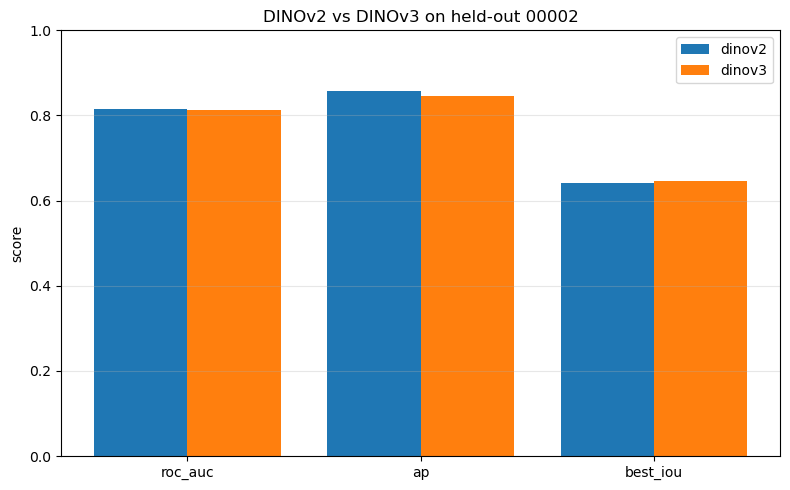

In [10]:
print(f"{'backbone':<10}{'patch':>7}{'grid':>7}{'valMSE':>9}{'ROC-AUC':>9}{'AP':>8}{'bestIoU':>9}{'@thr':>10}{'IoU@3.5':>9}")
print('-' * 78)
for name in results:
    r = results[name]
    print(f"{name:<10}{r['patch']:>7}{r['grid']:>7}{r['best_val_mse']:>9.4f}"
          f"{r['roc_auc']:>9.3f}{r['ap']:>8.3f}{r['best_iou']:>9.3f}{r['best_iou_thresh']:>10.4g}{r['paper_iou']:>9.3f}")

print()
print('Notes:')
print(' - valMSE and the cost thresholds are NOT comparable across backbones (different feature scales).')
print(' - IoU@3.5 (the paper threshold) is only meaningful for DINOv2; for DINOv3 it just means')
print("   'predict everything traversable'. Compare backbones with ROC-AUC, AP and bestIoU.")

# bar chart of the main scores
names = list(results.keys())
metrics_to_plot = ['roc_auc', 'ap', 'best_iou']
x = np.arange(len(metrics_to_plot))
width = 0.8 / max(1, len(names))
plt.figure(figsize=(8, 5))
for i, name in enumerate(names):
    values = [results[name][m] for m in metrics_to_plot]
    plt.bar(x + i * width, values, width, label=name)
plt.xticks(x + width * (len(names) - 1) / 2, metrics_to_plot)
plt.ylim(0, 1); plt.ylabel('score'); plt.title('DINOv2 vs DINOv3 on held-out ' + HOLDOUT)
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(COMP_DIR / 'comparison_bar.png', dpi=120); plt.show()

In [11]:
# training loss curves
# NOTE: when REUSE_SAVED_AUTOENCODERS is True the models are loaded from disk, no training
# happens, and there is no curve to draw -- only a single validation value per backbone.
curves_to_draw = {}
loaded_only = {}
for name in loss_curves:
    train_losses, val_losses = loss_curves[name]
    if len(val_losses) >= 2:
        curves_to_draw[name] = val_losses
    else:
        loaded_only[name] = val_losses[0] if len(val_losses) == 1 else float('nan')

if len(curves_to_draw) > 0:
    plt.figure(figsize=(8, 5))
    for name, val_losses in curves_to_draw.items():
        plt.plot(val_losses, marker='o', markersize=3, label=name + ' val')
    plt.xlabel('epoch'); plt.ylabel('validation MSE'); plt.title('autoencoder training')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

for name, val in loaded_only.items():
    print(f'{name}: autoencoder was loaded from disk (no training this run), '
          f'final val MSE = {val:.4f}. Set REUSE_SAVED_AUTOENCODERS = False and re-run '
          'section 7 to retrain and see the full curve.')

dinov2: autoencoder was loaded from disk (no training this run), final val MSE = 0.2416. Set REUSE_SAVED_AUTOENCODERS = False and re-run section 7 to retrain and see the full curve.
dinov3: autoencoder was loaded from disk (no training this run), final val MSE = 0.0034. Set REUSE_SAVED_AUTOENCODERS = False and re-run section 7 to retrain and see the full curve.


## 9. Save the results

In [12]:
summary = {
    'note': 'fresh autoencoders trained from scratch (not STEPP weights)',
    'train_seqs': TRAIN_SEQS,
    'holdout': HOLDOUT,
    'results': results,
}
with open(COMP_DIR / 'comparison_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('saved ->', COMP_DIR / 'comparison_metrics.json')
print(json.dumps(results, indent=2))

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\comp_v2v3\comparison_metrics.json
{
  "dinov2": {
    "roc_auc": 0.8156726744019478,
    "ap": 0.8579886518775518,
    "best_iou": 0.6420660733069298,
    "best_iou_thresh": 1.6529840230941772,
    "paper_iou": 0.5884984643155896,
    "patch": 14,
    "grid": 50,
    "best_val_mse": 0.2415662407875061
  },
  "dinov3": {
    "roc_auc": 0.8124933639403351,
    "ap": 0.8448252644851578,
    "best_iou": 0.6461997490133065,
    "best_iou_thresh": 0.040992086504896476,
    "paper_iou": 0.5563271084337349,
    "patch": 16,
    "grid": 44,
    "best_val_mse": 0.0034256663639098406
  }
}


## 10. Visual check: cost maps and traversability masks

Numbers are abstract — these cells show what the models actually "see" on a few held-out
images:
- the **original image** and the **ground truth** (RELLIS labels, green = traversable),
- each backbone's **cost map** (dark = low cost = familiar/traversable, bright = high cost =
  unfamiliar/obstacle),
- each backbone's **binary traversable mask** at its own best threshold.

The first cell gathers everything (it loads each backbone once and reuses the saved
autoencoders); the following cells only draw.

In [13]:
# ---- gather everything we need for the visualizations ----
N_SHOW = 3   # how many holdout images to display

pairs = get_holdout_pairs()
show_pairs = [pairs[len(pairs) // 6], pairs[len(pairs) // 2], pairs[(5 * len(pairs)) // 6]][:N_SHOW]

# best thresholds: use the in-memory results if available, otherwise the saved json
if 'results' in globals():
    saved_results = results
else:
    saved_results = json.load(open(COMP_DIR / 'comparison_metrics.json'))['results']

viz = {}
for backbone_name in BACKBONES:
    model, input_size, patch, grid = load_backbone(backbone_name)
    autoencoder = Autoencoder(384, HIDDEN_SIZES).to(device)
    autoencoder.load_state_dict(torch.load(COMP_DIR / f'autoencoder_{backbone_name}.pth', map_location=device))
    autoencoder.eval()

    # cost map for each image we want to show
    cost_maps = []
    for image_path, label_path in show_pairs:
        bgr = cv2.imread(str(image_path))
        cost_maps.append(make_cost_map(model, input_size, grid, autoencoder, bgr))

    # detailed data for the FIRST shown image: every segment's feature and its reconstruction
    bgr = cv2.imread(str(show_pairs[0][0]))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    square = cv2.resize(rgb, (input_size, input_size))
    segment_image = run_slic(square)
    feature_map = get_feature_map(model, square)
    small_segments = resize_segments(segment_image, grid)
    segment_ids = np.unique(small_segments)
    vectors, ids_kept = average_features_per_segment(feature_map, small_segments, segment_ids)
    with torch.no_grad():
        x = torch.from_numpy(vectors).to(device)
        reconstructions = autoencoder(x).cpu().numpy()
    segment_costs = ((vectors - reconstructions) ** 2).mean(axis=1)

    viz[backbone_name] = {
        'cost_maps': cost_maps,
        'threshold': saved_results[backbone_name]['best_iou_thresh'],
        'square': square,
        'segment_image': segment_image,
        'ids_kept': ids_kept,
        'vectors': vectors,
        'reconstructions': reconstructions,
        'segment_costs': segment_costs,
    }

    # free GPU memory before loading the next backbone
    del model, autoencoder
    torch.cuda.empty_cache()

print('visualization data ready for:', list(viz.keys()))

dinov2: input 700, patch 14, feature grid 50x50
dinov3: input 704, patch 16, feature grid 44x44
visualization data ready for: ['dinov2', 'dinov3']


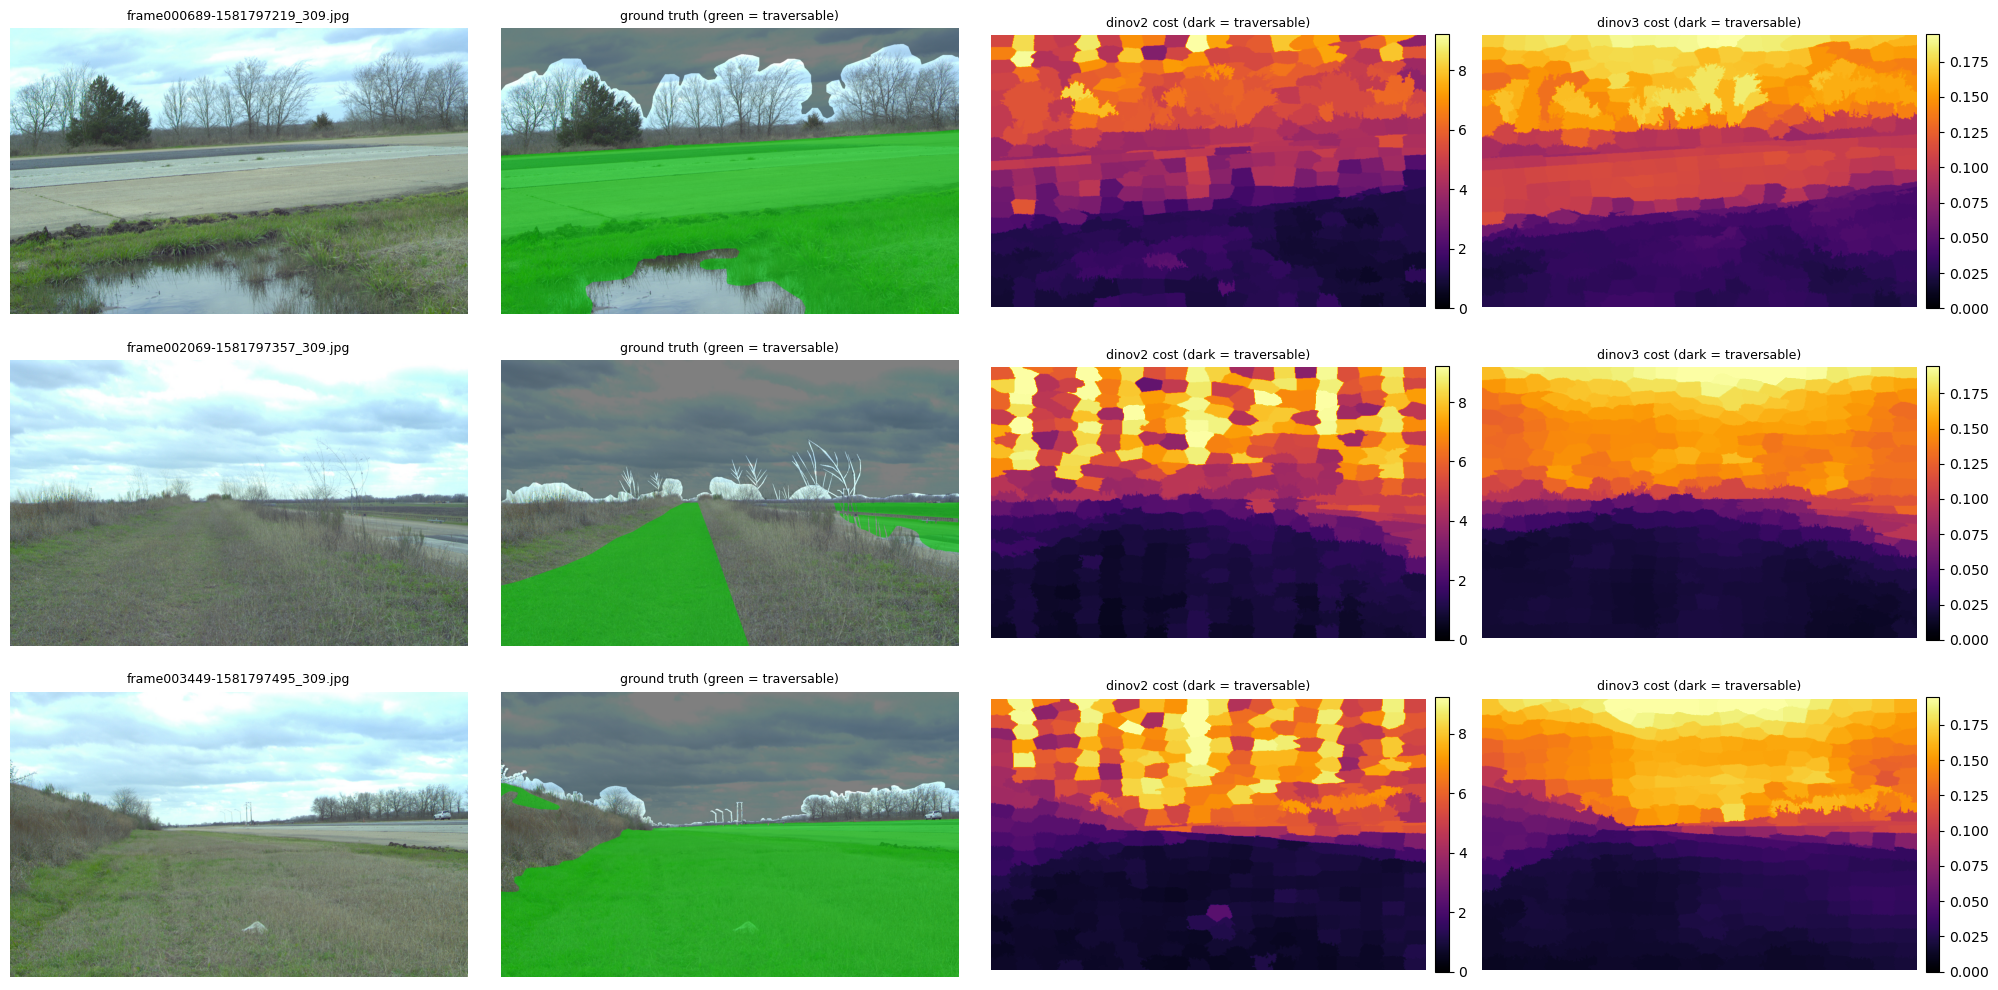

In [14]:
# ---- figure 1: original | ground truth | cost map per backbone ----
n_rows = len(show_pairs)
n_cols = 2 + len(BACKBONES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.4 * n_rows))
if n_rows == 1:
    axes = axes[None, :]     # keep 2-D indexing even with a single row

# each backbone gets ONE brightness scale across all its shown images,
# so its maps are comparable to each other (but NOT across backbones -- different scales!)
vmax = {}
for name in BACKBONES:
    all_costs = np.concatenate([c.ravel() for c in viz[name]['cost_maps']])
    vmax[name] = np.percentile(all_costs, 99)

for row in range(n_rows):
    image_path, label_path = show_pairs[row]
    bgr = cv2.imread(str(image_path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    label_image = cv2.imread(str(label_path), cv2.IMREAD_UNCHANGED)
    gt = make_ground_truth(label_image)

    # column 0: the photo
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(image_path.name, fontsize=9)

    # column 1: ground truth (green = traversable, dimmed = ignore)
    gt_vis = rgb.copy()
    gt_vis[gt == 1] = (0.4 * gt_vis[gt == 1] + 0.6 * np.array([0, 200, 0])).astype(np.uint8)
    gt_vis[gt == -1] = (0.5 * gt_vis[gt == -1]).astype(np.uint8)
    axes[row, 1].imshow(gt_vis)
    axes[row, 1].set_title('ground truth (green = traversable)', fontsize=9)

    # one column per backbone: the cost map
    for j, name in enumerate(BACKBONES):
        im = axes[row, 2 + j].imshow(viz[name]['cost_maps'][row], cmap='inferno', vmin=0, vmax=vmax[name])
        axes[row, 2 + j].set_title(f'{name} cost (dark = traversable)', fontsize=9)
        fig.colorbar(im, ax=axes[row, 2 + j], fraction=0.03, pad=0.02)

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.savefig(COMP_DIR / 'viz_cost_maps.png', dpi=120)
plt.show()

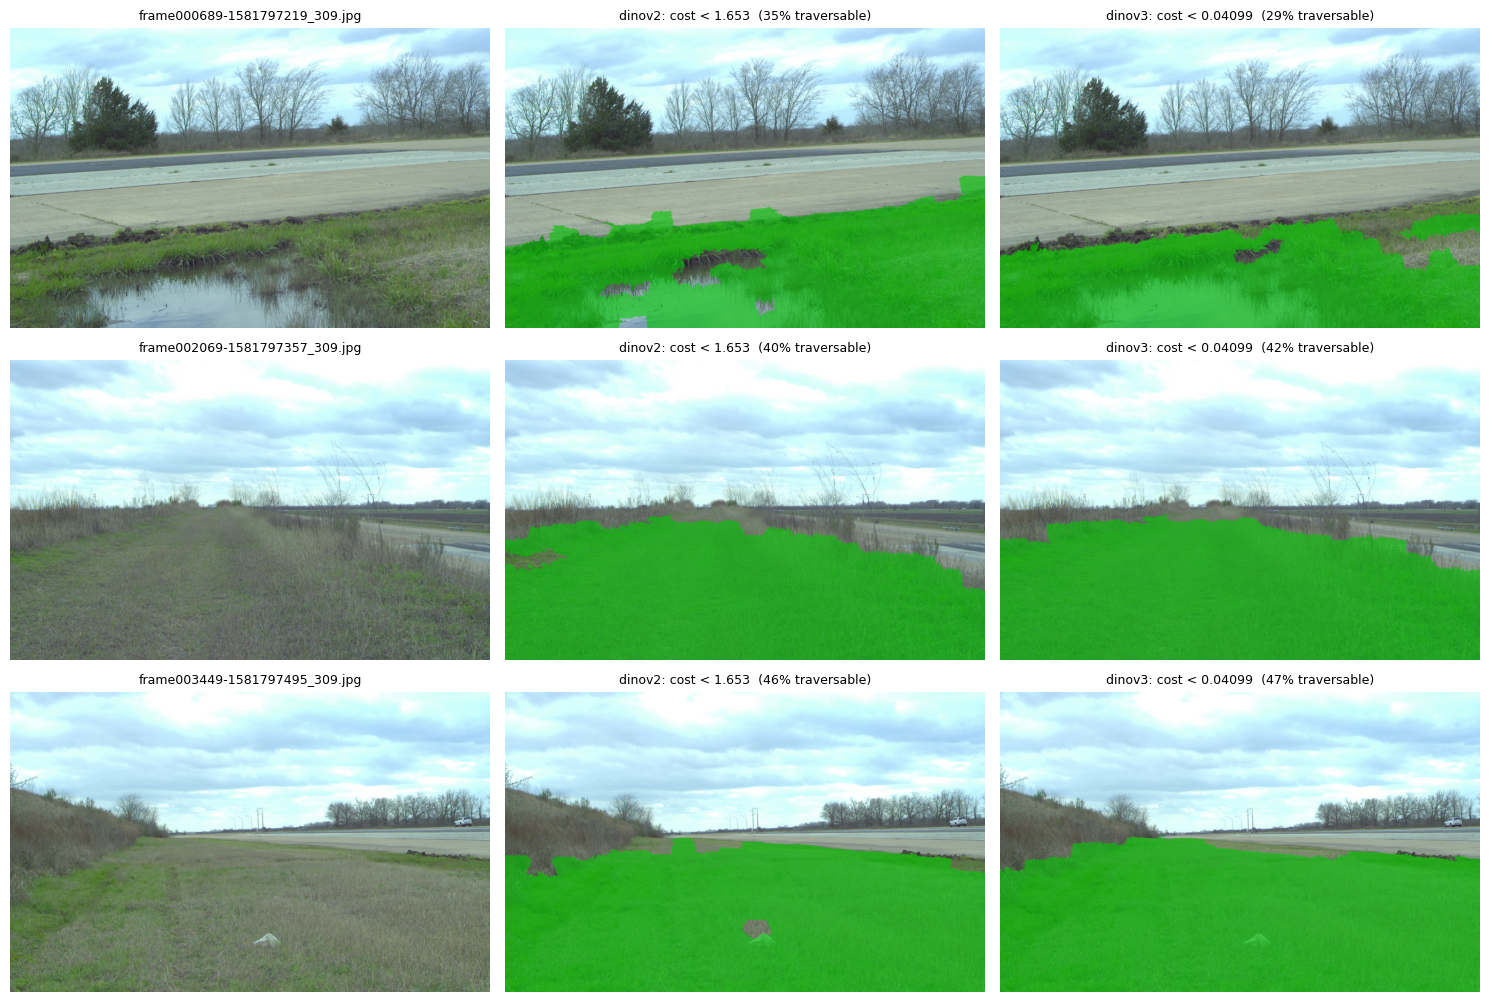

In [15]:
# ---- figure 2: binary traversable masks at each backbone's own best threshold ----
n_rows = len(show_pairs)
n_cols = 1 + len(BACKBONES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.4 * n_rows))
if n_rows == 1:
    axes = axes[None, :]     # keep 2-D indexing even with a single row

for row in range(n_rows):
    image_path, label_path = show_pairs[row]
    bgr = cv2.imread(str(image_path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(image_path.name, fontsize=9)

    for j, name in enumerate(BACKBONES):
        cost = viz[name]['cost_maps'][row]
        thresh = viz[name]['threshold']
        predicted_traversable = cost < thresh

        mask_vis = rgb.copy()
        mask_vis[predicted_traversable] = (0.4 * mask_vis[predicted_traversable]
                                           + 0.6 * np.array([0, 200, 0])).astype(np.uint8)
        pct = 100.0 * predicted_traversable.mean()
        axes[row, 1 + j].imshow(mask_vis)
        axes[row, 1 + j].set_title(f'{name}: cost < {thresh:.4g}  ({pct:.0f}% traversable)', fontsize=9)

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.savefig(COMP_DIR / 'viz_masks.png', dpi=120)
plt.show()

## 11. Actual vs reconstructed features — seeing the autoencoder at work

The autoencoder never sees images, only 384-number feature vectors. Its whole job is to output
a copy of its input, and the **gap between input and output is the cost**.

Below, for the first shown image: the left panel marks the segment the model reconstructs
**best** (green outline = most familiar = most traversable-looking) and **worst** (red outline
= least familiar). The plots show the actual feature (blue) and the reconstruction (orange)
for those two segments — for the familiar segment the two lines sit almost on top of each
other; for the unfamiliar one they visibly disagree.

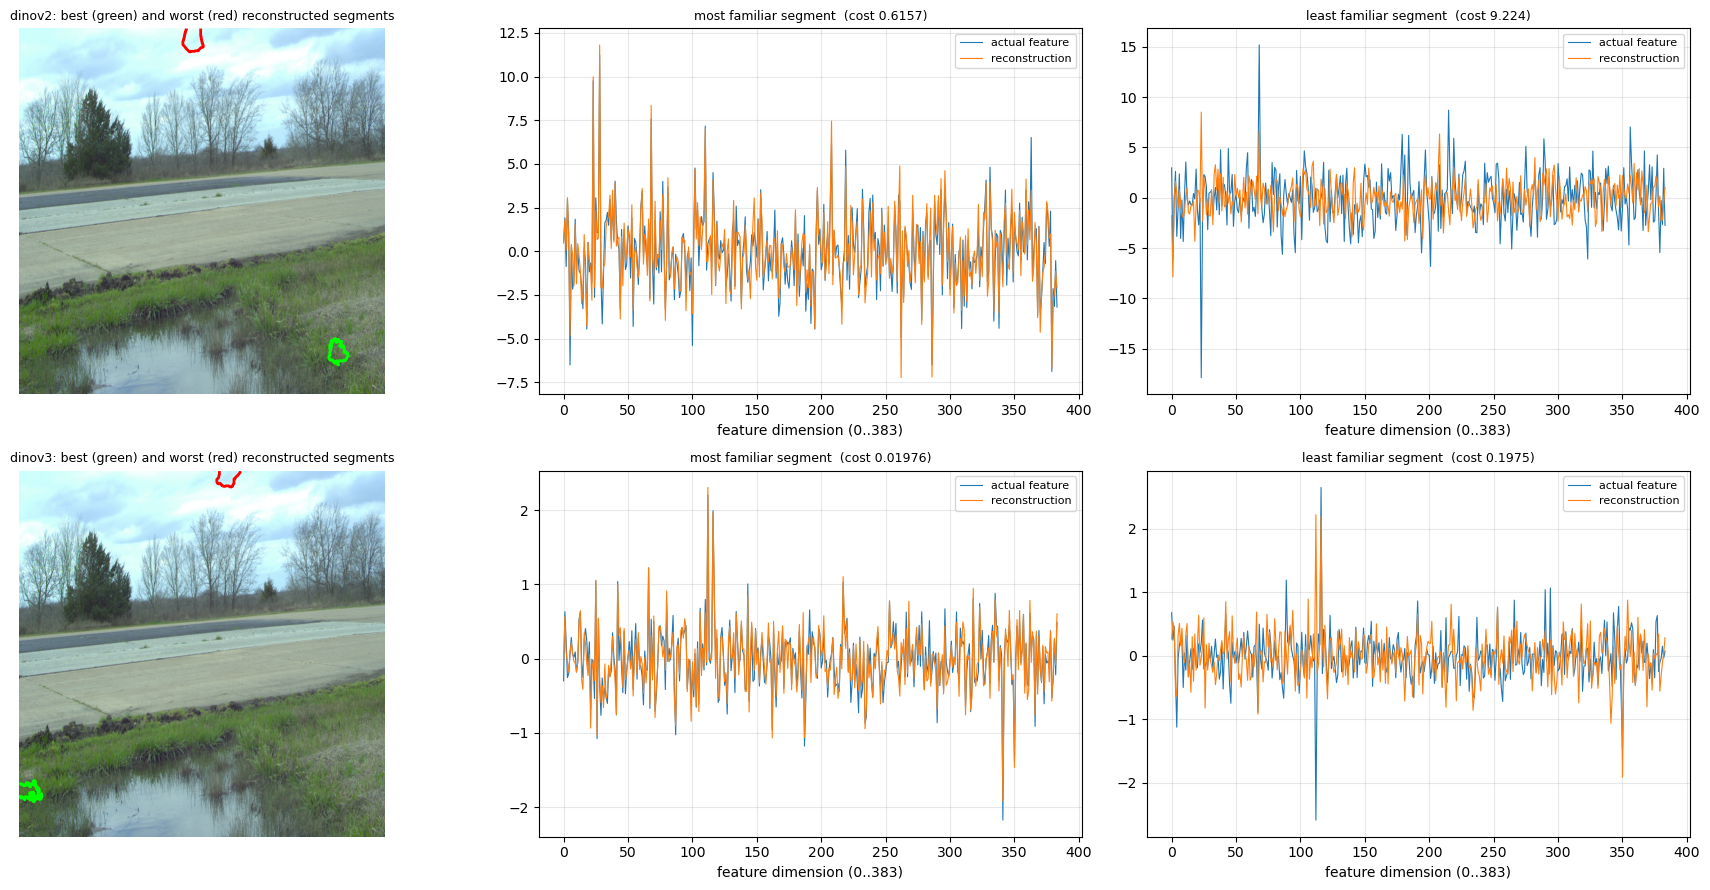

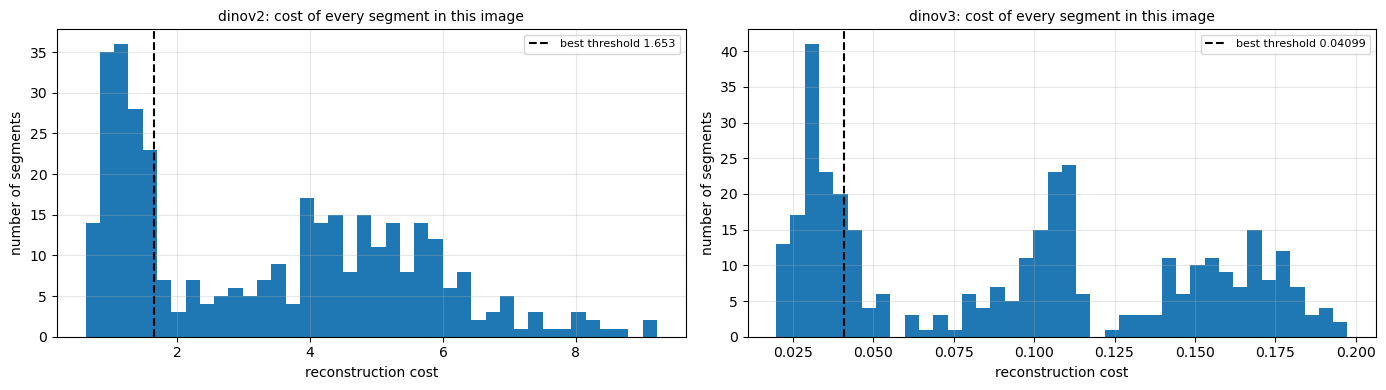

In [16]:
# ---- figure 3: where the best/worst segments are + actual vs reconstructed feature plots ----
fig, axes = plt.subplots(len(BACKBONES), 3, figsize=(18, 4.5 * len(BACKBONES)))
if len(BACKBONES) == 1:
    axes = axes[None, :]

for i, name in enumerate(BACKBONES):
    v = viz[name]
    best_idx  = int(np.argmin(v['segment_costs']))    # most familiar segment
    worst_idx = int(np.argmax(v['segment_costs']))    # least familiar segment
    best_id  = v['ids_kept'][best_idx]
    worst_id = v['ids_kept'][worst_idx]

    # left: the image with the two segments outlined
    ax = axes[i, 0]
    ax.imshow(v['square'])
    ax.contour(v['segment_image'] == best_id,  levels=[0.5], colors='lime', linewidths=2)
    ax.contour(v['segment_image'] == worst_id, levels=[0.5], colors='red',  linewidths=2)
    ax.set_title(f'{name}: best (green) and worst (red) reconstructed segments', fontsize=9)
    ax.axis('off')

    # middle: the familiar segment -- lines overlap almost perfectly
    ax = axes[i, 1]
    ax.plot(v['vectors'][best_idx], color='tab:blue', linewidth=0.8, label='actual feature')
    ax.plot(v['reconstructions'][best_idx], color='tab:orange', linewidth=0.8, label='reconstruction')
    ax.set_title(f'most familiar segment  (cost {v["segment_costs"][best_idx]:.4g})', fontsize=9)
    ax.set_xlabel('feature dimension (0..383)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # right: the unfamiliar segment -- the reconstruction clearly misses
    ax = axes[i, 2]
    ax.plot(v['vectors'][worst_idx], color='tab:blue', linewidth=0.8, label='actual feature')
    ax.plot(v['reconstructions'][worst_idx], color='tab:orange', linewidth=0.8, label='reconstruction')
    ax.set_title(f'least familiar segment  (cost {v["segment_costs"][worst_idx]:.4g})', fontsize=9)
    ax.set_xlabel('feature dimension (0..383)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(COMP_DIR / 'viz_reconstruction.png', dpi=120)
plt.show()

# also show the numeric spread of segment costs per backbone (histogram)
fig, axes = plt.subplots(1, len(BACKBONES), figsize=(7 * len(BACKBONES), 4))
if len(BACKBONES) == 1:
    axes = [axes]
for ax, name in zip(axes, BACKBONES):
    ax.hist(viz[name]['segment_costs'], bins=40, color='tab:blue')
    ax.axvline(viz[name]['threshold'], color='black', linestyle='--',
               label=f'best threshold {viz[name]["threshold"]:.4g}')
    ax.set_title(f'{name}: cost of every segment in this image', fontsize=10)
    ax.set_xlabel('reconstruction cost'); ax.set_ylabel('number of segments')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. How the evaluation works, and what each metric means

### How a prediction is scored at all

For every evaluated pixel of the held-out sequence we have two things:

- **the model's cost** — the autoencoder's reconstruction error at that pixel (low = the
  terrain looks familiar/traversable, high = unfamiliar/obstacle);
- **the truth** — the RELLIS label collapsed to *traversable* (grass, dirt, asphalt, concrete,
  mud, puddle) or *obstacle* (trees, bushes, people, vehicles, …). Sky and void are ignored.

To turn a cost into a yes/no answer you pick a **threshold**: predict "traversable" wherever
`cost < threshold`. Every prediction then falls into one of four boxes:

| | truly traversable | truly obstacle |
|---|---|---|
| predicted traversable | **TP** (true positive) | **FP** — dangerous: robot drives into an obstacle |
| predicted obstacle | **FN** — over-cautious: robot avoids fine ground | **TN** (true negative) |

All metrics below are different summaries of those four numbers.

### ROC-AUC (threshold-free) — *the fairest comparison number*

Instead of picking one threshold, sweep **every possible threshold** and, at each one, plot the
true-positive rate against the false-positive rate. The area under that curve is the ROC-AUC.

- **1.0** = perfect: there is some threshold that separates every traversable pixel from every
  obstacle pixel. **0.5** = coin flip.
- Intuition: *"pick a random traversable pixel and a random obstacle pixel — how often does the
  model give the traversable one the lower cost?"* ROC-AUC is exactly that probability.
- Because it never commits to a threshold, it is **immune to the cost-scale problem** (DINOv3's
  costs being ~100× smaller than DINOv2's doesn't matter). This is the headline number for
  comparing backbones.

### AP — Average Precision (threshold-free)

Same idea as ROC-AUC but summarizing the **precision–recall** trade-off: sweep all thresholds
and average the precision (*"of the pixels I called traversable, how many really were?"*)
across recall levels (*"how many of the truly traversable pixels did I find?"*). It weights
mistakes on the traversable class more directly than ROC-AUC, so it's a good companion number.
1.0 = perfect; the baseline for a useless model equals the traversable fraction (~0.56 here).

### best IoU and its threshold

**IoU (Intersection over Union)** for the traversable class at one threshold:

$$IoU = \frac{TP}{TP + FP + FN}$$

— the overlap between the predicted-traversable region and the truly-traversable region,
as a fraction of their union. 1.0 = the two regions coincide exactly. It punishes **both**
kinds of error (false alarms and misses), which is why it's the standard segmentation metric.

**best IoU** = the highest IoU over a sweep of thresholds — "how good could this model be if we
tuned its threshold perfectly?" (an oracle upper bound; the STEPP paper also tuned per dataset).
The sweep uses **quantiles of the observed costs** rather than a fixed grid, so it adapts to
each backbone's own cost scale and treats both fairly.

**@thr** is simply the threshold where that best IoU occurred. Note it is in each backbone's
own cost units, so a DINOv2 threshold of ~1.7 and a DINOv3 threshold of ~0.003 are *not*
comparable — only the resulting IoUs are.

### IoU@3.5 — the paper threshold (context only)

The STEPP paper caps costs at 10, normalizes to 0–1 and thresholds at 0.35, i.e. a raw cost of
**3.5**. We report IoU at that fixed value for continuity with the paper — but it is only
meaningful on **DINOv2's** cost scale. For DINOv3 essentially every cost is below 3.5, so this
column degenerates to "predict everything traversable" (IoU ≈ the traversable fraction, ~0.56)
and should be ignored for that backbone.

### valMSE — the training-side number (not a comparison metric!)

The autoencoder's reconstruction error on the 20% validation split of the *training* features.
It only says "training converged". It **cannot** be compared across backbones because MSE
scales with the feature variance, and DINOv3 features are numerically ~6× smaller than
DINOv2's — that alone explains 0.0034 vs 0.24, and says nothing about which backbone is better.

### One honest caveat

The evaluation samples `PIXELS_PER_FRAME = 4000` random (non-ignore) pixels per frame instead
of all ~2.3 million, to keep memory small. With ~240 frames that is ~1M samples — plenty for
stable metrics (they move by <0.01 vs. using every pixel), but it is why re-runs can differ in
the third decimal.

## 13. Digging into single classes: mud, puddle, water & friends

Some RELLIS classes are genuinely debatable: is **mud** traversable? A **puddle**? So far we
made one choice (both = traversable) and baked it into the metrics. Here we look at how the
two backbones treat **each class on its own**.

**No retraining is needed for any of this.** The autoencoders were trained only on "terrain
the robot drove over" — the labels were never used in training. Labels only enter when we
*score* the predictions, so changing a class from traversable to obstacle just changes the
scoring, not the models.

The cell below runs both models over a set of held-out frames and records, for a sample of
pixels, **the cost from each backbone and the true RELLIS class** of that pixel. The same
pixels are used for both backbones, so the comparison is exact. Everything after that is just
different ways of slicing this one table.

In [17]:
# ---- collect (cost, class) for the SAME sample pixels with both backbones ----
PER_CLASS_EVERY   = 4      # use every 4th evaluation frame (speed; lower = more frames)
SAMPLES_PER_FRAME = 6000   # pixels sampled per frame

# human-readable names for the RELLIS label ids
CLASS_NAMES = {0: 'void', 1: 'dirt', 3: 'grass', 4: 'tree', 5: 'pole', 6: 'water',
               7: 'sky', 8: 'vehicle', 9: 'object', 10: 'asphalt', 12: 'building',
               15: 'log', 17: 'person', 18: 'fence', 19: 'bush', 23: 'concrete',
               27: 'barrier', 31: 'puddle', 33: 'mud', 34: 'rubble'}

# best thresholds from the earlier evaluation (fall back to the saved file if needed)
if 'results' in globals():
    saved_results = results
else:
    saved_results = json.load(open(COMP_DIR / 'comparison_metrics.json'))['results']

analysis_pairs = get_holdout_pairs()[::PER_CLASS_EVERY]
print('frames used for the class analysis:', len(analysis_pairs))

costs_by_backbone = {}     # backbone name -> one long array of costs
pixel_classes = None       # the RELLIS class id of each sampled pixel (same for both)

for backbone_name in BACKBONES:
    model, input_size, patch, grid = load_backbone(backbone_name)
    autoencoder = Autoencoder(384, HIDDEN_SIZES).to(device)
    autoencoder.load_state_dict(torch.load(COMP_DIR / f'autoencoder_{backbone_name}.pth', map_location=device))
    autoencoder.eval()

    frame_costs = []
    frame_classes = []
    for frame_index, (image_path, label_path) in enumerate(analysis_pairs):
        bgr = cv2.imread(str(image_path))
        label_image = cv2.imread(str(label_path), cv2.IMREAD_UNCHANGED)
        cost = make_cost_map(model, input_size, grid, autoencoder, bgr)

        usable = ~np.isin(label_image, IGNORE_IDS)         # drop void and sky pixels
        usable_costs = cost[usable]
        usable_classes = label_image[usable]

        # seed depends only on the frame number -> BOTH backbones pick the SAME pixels
        rng = np.random.RandomState(frame_index)
        n_pick = min(SAMPLES_PER_FRAME, len(usable_costs))
        pick = rng.choice(len(usable_costs), n_pick, replace=False)
        frame_costs.append(usable_costs[pick])
        frame_classes.append(usable_classes[pick])

        if frame_index % 20 == 0:
            print(f'   {backbone_name}: {frame_index}/{len(analysis_pairs)} frames')

    costs_by_backbone[backbone_name] = np.concatenate(frame_costs)
    if pixel_classes is None:
        pixel_classes = np.concatenate(frame_classes)

    del model, autoencoder
    torch.cuda.empty_cache()

present_classes = sorted(np.unique(pixel_classes).tolist())
print('\ntotal sampled pixels:', len(pixel_classes))
print('classes present in the holdout frames:',
      [f'{c} ({CLASS_NAMES.get(c, "?")})' for c in present_classes])

frames used for the class analysis: 104
dinov2: input 700, patch 14, feature grid 50x50
   dinov2: 0/104 frames
   dinov2: 20/104 frames
   dinov2: 40/104 frames
   dinov2: 60/104 frames
   dinov2: 80/104 frames
   dinov2: 100/104 frames
dinov3: input 704, patch 16, feature grid 44x44
   dinov3: 0/104 frames
   dinov3: 20/104 frames
   dinov3: 40/104 frames
   dinov3: 60/104 frames
   dinov3: 80/104 frames
   dinov3: 100/104 frames

total sampled pixels: 624000
classes present in the holdout frames: ['1 (dirt)', '3 (grass)', '4 (tree)', '5 (pole)', '6 (water)', '8 (vehicle)', '9 (object)', '10 (asphalt)', '12 (building)', '17 (person)', '19 (bush)', '23 (concrete)', '27 (barrier)', '31 (puddle)', '33 (mud)']


class          pixels dinov2 med.cost  dinov2 %trav dinov3 med.cost  dinov3 %trav
---------------------------------------------------------------------------------
dirt                2           4.705          0.0%          0.1102          0.0%
grass          309077          0.9564         90.6%         0.02077         92.7%
tree            53748           5.346          0.0%          0.1288          0.2%
pole              472           5.395          0.0%           0.131          0.0%
water            2012           1.391         69.0%         0.03591         84.5%
vehicle           711           5.485          0.0%           0.112          0.4%
object            565            5.16          0.0%          0.1073          1.1%
asphalt          1717           4.858          0.0%          0.1015          0.1%
building          330            5.67          0.0%           0.117          0.0%
person            191            6.13          0.0%         0.09297          1.6%
bush           2

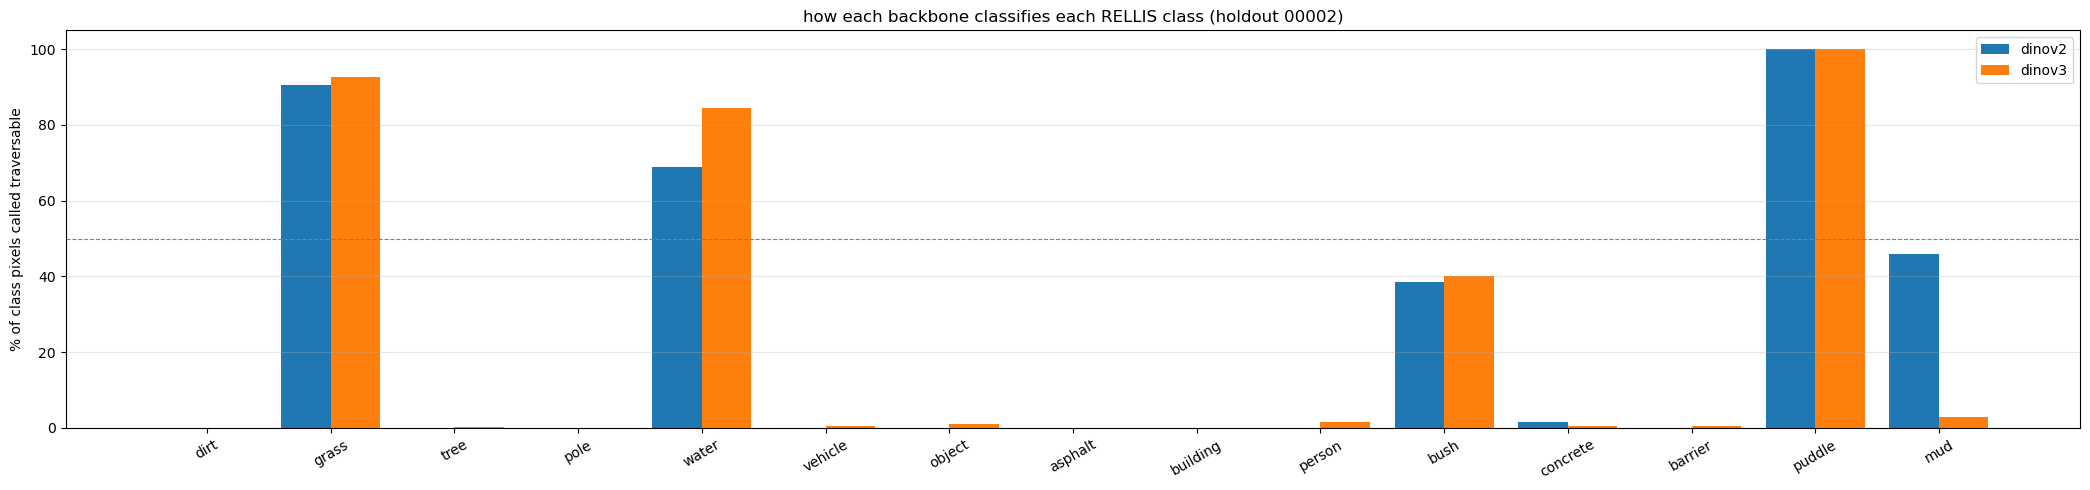

In [18]:
# ---- per-class table: how does each backbone treat each class? ----
# "% called traversable" = share of that class's pixels with cost below the backbone's
# best threshold. For classes we consider traversable we WANT a high %, for obstacles a low %.

print(f"{'class':<12}{'pixels':>9}", end='')
for name in BACKBONES:
    print(f"{name + ' med.cost':>16}{name + ' %trav':>14}", end='')
print()
print('-' * (21 + 30 * len(BACKBONES)))

percent_traversable = {name: {} for name in BACKBONES}
for class_id in present_classes:
    mask = pixel_classes == class_id
    class_name = CLASS_NAMES.get(class_id, f'id {class_id}')
    print(f"{class_name:<12}{mask.sum():>9}", end='')
    for name in BACKBONES:
        costs = costs_by_backbone[name][mask]
        thresh = saved_results[name]['best_iou_thresh']
        pct = 100.0 * np.mean(costs < thresh)
        percent_traversable[name][class_id] = pct
        print(f"{np.median(costs):>16.4g}{pct:>13.1f}%", end='')
    print()

print('\n(cost values are NOT comparable between backbones -- only the percentages are)')

# ---- bar chart of the percentages ----
class_labels = [CLASS_NAMES.get(c, str(c)) for c in present_classes]
x = np.arange(len(present_classes))
width = 0.8 / len(BACKBONES)

plt.figure(figsize=(1.2 * len(present_classes) + 3, 5))
for i, name in enumerate(BACKBONES):
    values = [percent_traversable[name][c] for c in present_classes]
    plt.bar(x + i * width, values, width, label=name)
plt.xticks(x + width * (len(BACKBONES) - 1) / 2, class_labels, rotation=30)
plt.ylabel('% of class pixels called traversable')
plt.title(f'how each backbone classifies each RELLIS class (holdout {HOLDOUT})')
plt.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(COMP_DIR / 'per_class_traversable.png', dpi=120)
plt.show()

## 14. What if mud / puddle were counted as obstacles?

The metrics depend on our label choice. Since we saved every sampled pixel's cost **and** its
class, we can re-score the same predictions under different definitions of "traversable"
instantly — no model is touched, no cost map recomputed. This shows how sensitive the
DINOv2-vs-DINOv3 comparison is to the debatable classes.

scenario                              backbone    ROC-AUC      AP  bestIoU
--------------------------------------------------------------------------
default  (mud + puddle traversable)   dinov2        0.820   0.864    0.648
default  (mud + puddle traversable)   dinov3        0.822   0.860    0.655

mud -> obstacle                       dinov2        0.821   0.864    0.648
mud -> obstacle                       dinov3        0.824   0.860    0.657

puddle -> obstacle                    dinov2        0.820   0.864    0.648
puddle -> obstacle                    dinov3        0.822   0.860    0.655

strict   (both -> obstacle)           dinov2        0.821   0.864    0.648
strict   (both -> obstacle)           dinov3        0.824   0.860    0.657

pavement -> obstacle                  dinov2        0.902   0.894    0.711
pavement -> obstacle                  dinov3        0.906   0.889    0.722



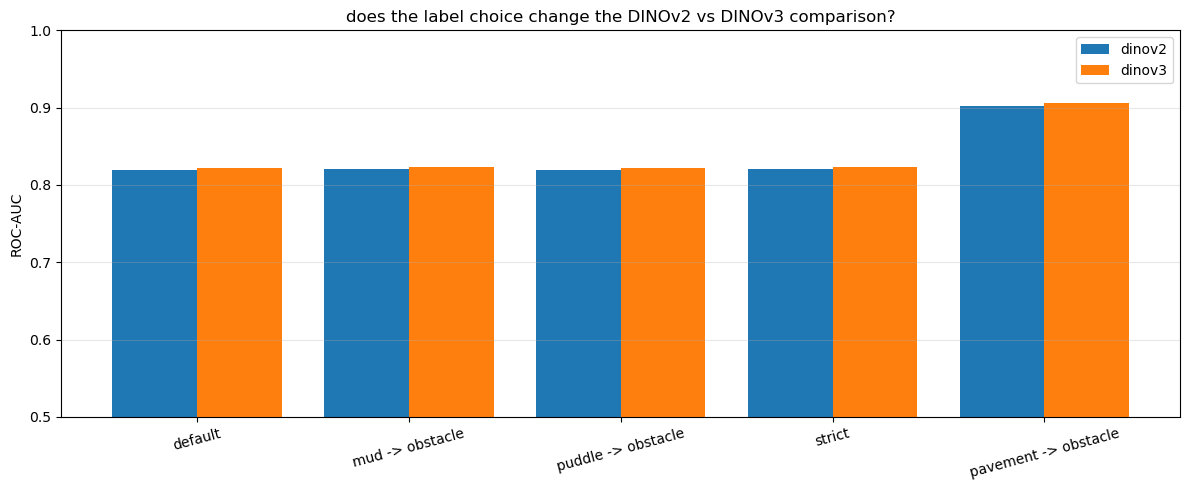

In [19]:
# ---- re-score the SAME predictions under different label choices ----
# each scenario is just a different set of class ids that count as "traversable"
SCENARIOS = {
    'default  (mud + puddle traversable)': [1, 3, 10, 23, 33, 31],
    'mud -> obstacle'                    : [1, 3, 10, 23, 31],
    'puddle -> obstacle'                 : [1, 3, 10, 23, 33],
    'strict   (both -> obstacle)'        : [1, 3, 10, 23],
    # the robot trained on grass/dirt trails and (almost) never drove on pavement,
    # so asphalt/concrete look "unfamiliar" to it -- this scenario scores the models
    # only on the terrain the robot could actually have learned:
    'pavement -> obstacle'               : [1, 3, 33, 31],
}

print(f"{'scenario':<38}{'backbone':<10}{'ROC-AUC':>9}{'AP':>8}{'bestIoU':>9}")
print('-' * 74)
scenario_results = {}
for scenario_name, traversable_ids in SCENARIOS.items():
    binary_labels = np.isin(pixel_classes, traversable_ids).astype(int)
    for name in BACKBONES:
        scores = score_predictions(costs_by_backbone[name], binary_labels)
        scenario_results[(scenario_name, name)] = scores
        print(f"{scenario_name:<38}{name:<10}{scores['roc_auc']:>9.3f}{scores['ap']:>8.3f}{scores['best_iou']:>9.3f}")
    print()

# ---- chart: ROC-AUC per scenario ----
scenario_names = list(SCENARIOS.keys())
x = np.arange(len(scenario_names))
width = 0.8 / len(BACKBONES)
plt.figure(figsize=(12, 5))
for i, name in enumerate(BACKBONES):
    values = [scenario_results[(s, name)]['roc_auc'] for s in scenario_names]
    plt.bar(x + i * width, values, width, label=name)
plt.xticks(x + width * (len(BACKBONES) - 1) / 2,
           [s.split('(')[0].strip() for s in scenario_names], rotation=15)
plt.ylabel('ROC-AUC'); plt.ylim(0.5, 1.0)
plt.title('does the label choice change the DINOv2 vs DINOv3 comparison?')
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(COMP_DIR / 'scenario_comparison.png', dpi=120)
plt.show()

## 15. STEPP-style overlays: heatmap + red/green traversability

The STEPP paper shows its results as a color overlay on the photo: **green = traversable,
red = not traversable**. Here is the same view for both backbones, next to the cost heatmap,
using each backbone's own best threshold. (This reuses the cost maps computed in section 10 —
run that first.)

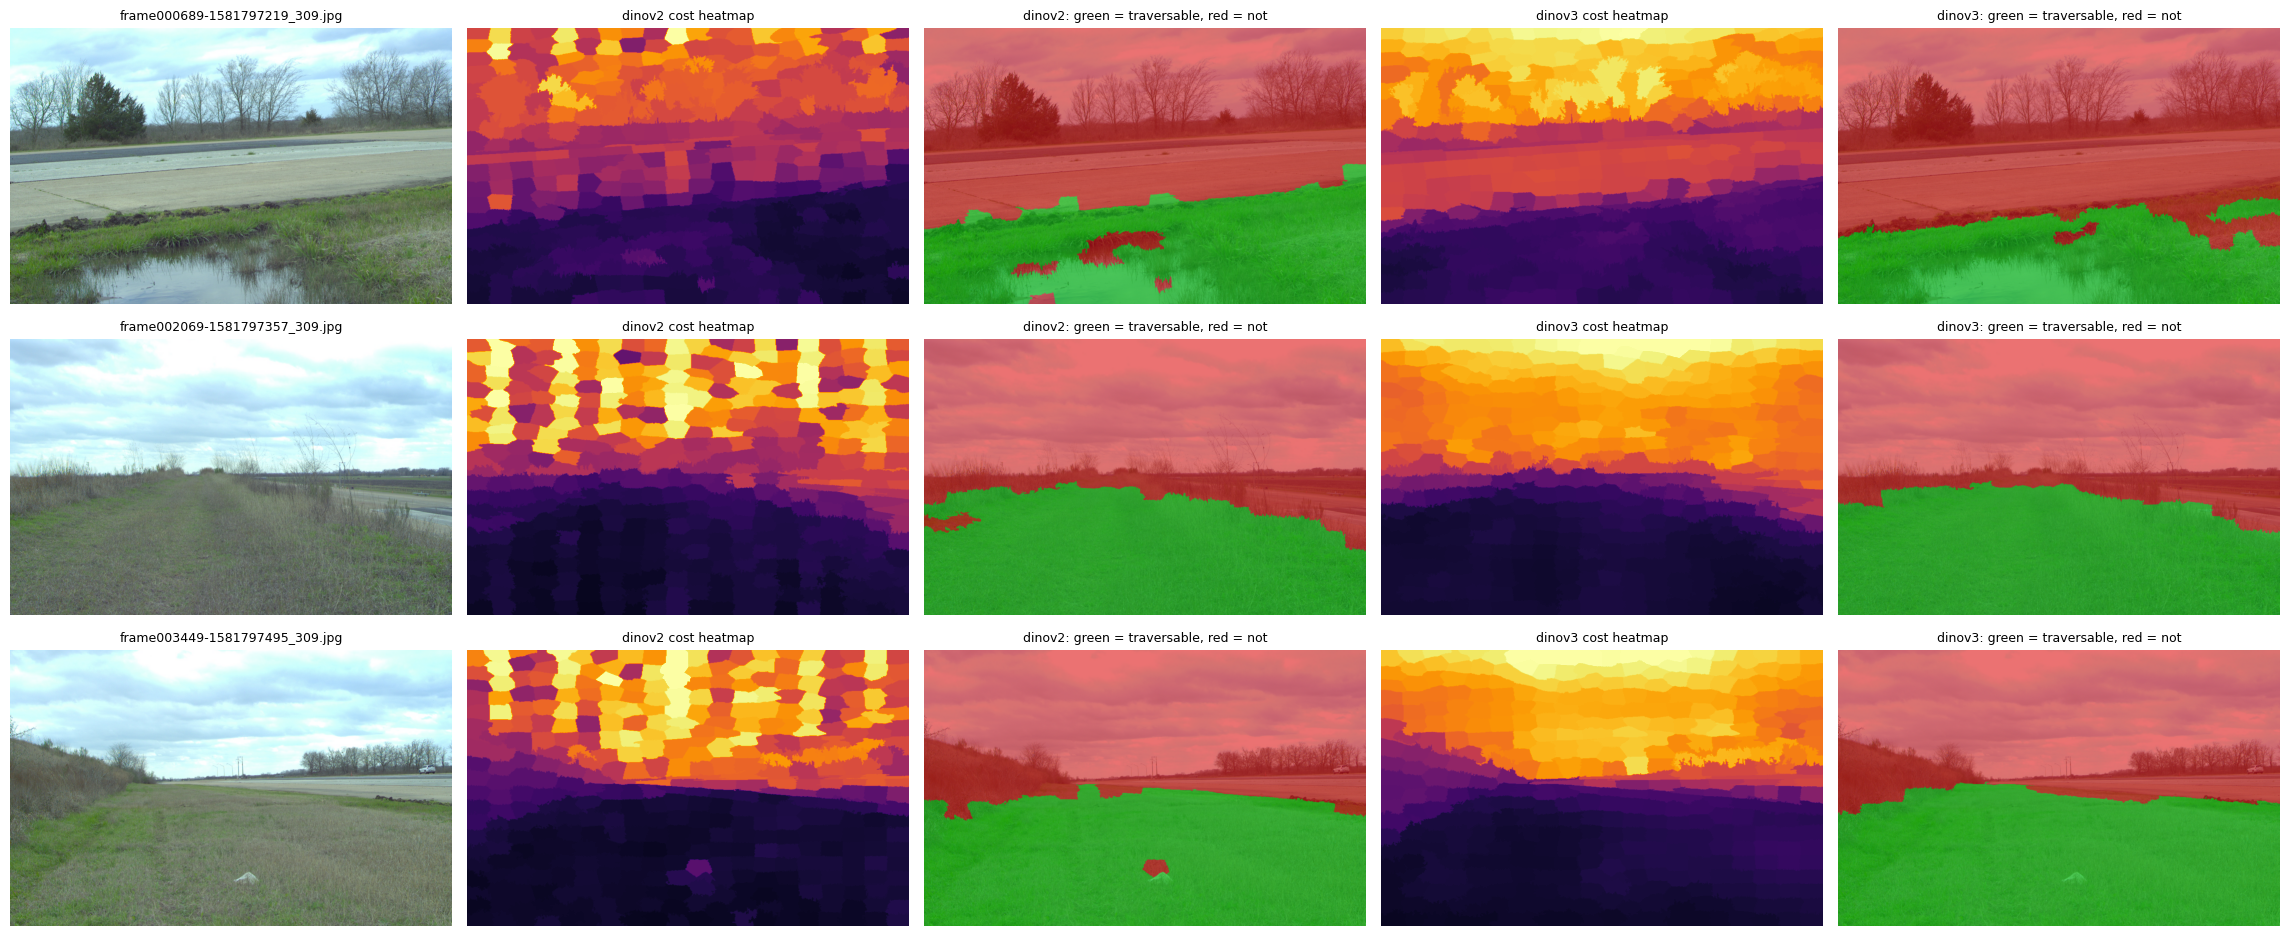

In [20]:
# ---- STEPP-style overlays: photo | heat + red/green for each backbone ----
def red_green_overlay(rgb, cost, thresh):
    """Green where the model says traversable (cost < thresh), red everywhere else."""
    out = rgb.copy()
    traversable = cost < thresh
    out[traversable]  = (0.45 * out[traversable]  + 0.55 * np.array([0, 200, 0])).astype(np.uint8)
    out[~traversable] = (0.45 * out[~traversable] + 0.55 * np.array([220, 0, 0])).astype(np.uint8)
    return out

n_rows = len(show_pairs)
n_cols = 1 + 2 * len(BACKBONES)          # photo + (heatmap, red/green) per backbone
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 3.2 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

for row in range(n_rows):
    image_path, label_path = show_pairs[row]
    bgr = cv2.imread(str(image_path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(image_path.name, fontsize=9)

    for j, name in enumerate(BACKBONES):
        cost = viz[name]['cost_maps'][row]              # computed in section 10
        thresh = viz[name]['threshold']

        # heatmap column (per-backbone brightness scale, like section 10)
        all_costs = np.concatenate([c.ravel() for c in viz[name]['cost_maps']])
        axes[row, 1 + 2 * j].imshow(cost, cmap='inferno', vmin=0, vmax=np.percentile(all_costs, 99))
        axes[row, 1 + 2 * j].set_title(f'{name} cost heatmap', fontsize=9)

        # STEPP-style red/green column
        axes[row, 2 + 2 * j].imshow(red_green_overlay(rgb, cost, thresh))
        axes[row, 2 + 2 * j].set_title(f'{name}: green = traversable, red = not', fontsize=9)

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.savefig(COMP_DIR / 'stepp_style_overlays.png', dpi=120)
plt.show()

## 16. Explanations for the class analysis (sections 13–15)

### Why no retraining was needed

The autoencoders learned from **odometry only**: "the robot drove over these superpixels, so
learn what they look like." The RELLIS class labels were never shown to the models. Labels are
only used afterwards, to *grade* the predictions. So questions like "what if mud counts as an
obstacle?" only change the grading sheet, not the student — we can re-grade the same
predictions under any label choice for free.

### How section 13 works (per-class table & bar chart)

For a set of held-out frames we record, per sampled pixel: its **cost from DINOv2**, its
**cost from DINOv3**, and its **true RELLIS class**. The same pixels are used for both
backbones (the random picker is seeded with the frame number), so differences between the
columns are purely model differences.

- **median cost** — the typical cost the backbone assigns to that class. Remember the two
  backbones' cost units are different scales, so compare *classes within one backbone*, never
  costs across backbones.
- **% called traversable** — the share of that class's pixels below the backbone's best
  threshold. This *is* comparable across backbones, and is the number to look at:
  - grass/dirt should be near 100%,
  - trees/bushes/people near 0%,
  - **mud and puddle are the interesting rows** — the robot *did* drive over muddy track
    during training, so some "mud" being called traversable is not a mistake, it's the
    self-supervised signal being honest about what the robot actually did.

### How section 14 works (label scenarios)

Each scenario redefines which class ids count as traversable, rebuilds the 0/1 truth for the
*same* sampled pixels, and recomputes ROC-AUC / AP / best-IoU. Read it two ways:

1. **Within one backbone:** if the score *drops* when mud becomes an obstacle, the model tends
   to call mud traversable (consistent with its training experience of driving on mud).
2. **Between backbones:** if the ranking (DINOv2 vs DINOv3) stays the same across all
   scenarios, the comparison conclusion is robust — it doesn't hinge on how we labeled the
   debatable classes.

### How to read the section 15 overlays

- **Heatmap** (dark→bright = low→high cost): the model's raw, continuous opinion. Each
  backbone has its own brightness scale, since their cost units differ.
- **Red/green** (STEPP-paper style): the final decision after applying the threshold —
  green = drive here, red = don't. This is what a robot's planner would consume.
- Comparing the two columns shows what the threshold throws away: a puddle might be mid-bright
  in the heatmap ("somewhat unusual") but still fall on the green side of the threshold.

### Honest caveats

- Costs are **per-superpixel**, so class boundaries are only as sharp as the SLIC segments —
  thin classes (poles, fences, distant people) inherit some cost from their surroundings.
- Classes with few sampled pixels (see the `pixels` column) give noisy percentages.
- The best thresholds used here were tuned under the *default* ontology; a planner that treats
  mud as forbidden would retune its threshold (section 14's best-IoU already does this
  per scenario).